In [2]:
import pandas as pd
from pathlib import Path
# SANTE-TERRITOIRES > notebooks > 01-expl-apl-occiatnie.ipynb
# ROOT = SANTE-TERRITOIRES

# ROOT = Path(__file__).parent.parent
# On essaie d'utiliser __file__, sinon on prend le dossier actuel
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

# Pour faire l'équivalent de .parent.parent :
ROOT = BASE_DIR.parent

DATA_DIR = ROOT / "data"

print(f'Le chemin DATA_DIR est: {DATA_DIR}')

# df = pd.read_parquet(DATA_DIR / 'processed/data/commune/score_sante_territoires_final.parquet')

df = pd.read_parquet(DATA_DIR / 'processed/data/commune/final_comm_indic_projet.parquet')

Le chemin DATA_DIR est: /Users/jean-jacques/code/jjchabutDataCRM/sante-territoires/data


In [3]:
df.head()

,code_insee_comm,nom_commune,population,superficie,apl_medecins,apl_65ans,apl_dentistes,apl_infirmiers,apl_kines,apl_sagesfemmes,...,codes_siren_des_epci,code_insee_de_la_region,tps_SU_SMUR,tx_mortalite,tx_mort_premature,tps_SU_SMUR_std,tx_mortalite_std,tx_mort_premature_std,apl_fragilite_std,score_fragilite_global
0,01001,L'Abergement-Clémenciat,859.0,1590.0,1.942,1.881,35.270,122.416,46.259,26.842,...,200069193,84,31.0,7.9,1.4,0.652248,-1.286679,-1.590381,0.317946,-0.206729
1,01002,L'Abergement-de-Varey,273.0,920.0,2.376,1.767,36.427,109.849,51.106,14.058,...,240100883,84,18.0,7.9,1.4,-0.441289,-1.286679,-1.590381,0.291066,-0.580201
2,01004,Ambérieu-en-Bugey,15554.0,2460.0,3.083,2.431,59.621,201.121,128.398,27.729,...,240100883,84,0.0,7.9,1.4,-1.955416,-1.286679,-1.590381,-0.778222,-1.441340
3,01005,Ambérieux-en-Dombes,1917.0,1590.0,3.706,3.648,50.539,131.876,113.357,30.500,...,200042497,84,23.5,7.9,1.4,0.021361,-1.286679,-1.590381,-0.583430,-0.717483
4,01006,Ambléon,114.0,590.0,0.889,0.775,10.929,44.227,21.023,11.887,...,200040350,84,15.0,7.9,1.4,-0.693643,-1.286679,-1.590381,1.231006,-0.351006


In [4]:
df.columns

Index(['code_insee_comm', 'nom_commune', 'population', 'superficie',
       'apl_medecins', 'apl_65ans', 'apl_dentistes', 'apl_infirmiers',
       'apl_kines', 'apl_sagesfemmes', 'delta_apl_medecins',
       'delta_apl_dentistes', 'delta_apl_infirmiers', 'delta_apl_kines',
       'delta_apl_sagesfemmes', 'apl_medecins_std', 'apl_dentistes_std',
       'apl_infirmiers_std', 'apl_kines_std', 'apl_sagesfemmes_std',
       'score_apl', 'quintile_apl_nat', 'code_insee_du_departement',
       'codes_siren_des_epci', 'code_insee_de_la_region', 'tps_SU_SMUR',
       'tx_mortalite', 'tx_mort_premature', 'tps_SU_SMUR_std',
       'tx_mortalite_std', 'tx_mort_premature_std', 'apl_fragilite_std',
       'score_fragilite_global'],
      dtype='object')

In [5]:
# 1. Liste de vos colonnes cibles
cols_to_weight = [
    'apl_medecins', 'apl_dentistes', 'apl_infirmiers', 'apl_kines', 
    'apl_sagesfemmes', 'delta_apl_medecins', 'delta_apl_dentistes', 
    'delta_apl_infirmiers', 'delta_apl_kines', 'delta_apl_sagesfemmes', 
    'apl_medecins_std', 'apl_dentistes_std', 'apl_infirmiers_std', 
    'apl_kines_std', 'apl_sagesfemmes_std', 
    'tx_mort_premature_std', 'tps_SU_SMUR_std'
]

# 2. Calcul de la moyenne pondérée
# On multiplie le DataFrame des colonnes par la série population
weighted_sums = df[cols_to_weight].multiply(df['population'], axis=0).sum()
total_population = df['population'].sum()

stats_france = weighted_sums / total_population

print(stats_france)

apl_medecins               3.548408
apl_dentistes             57.952660
apl_infirmiers           140.788987
apl_kines                112.045359
apl_sagesfemmes           20.229600
delta_apl_medecins         0.486054
delta_apl_dentistes       15.392707
delta_apl_infirmiers      17.121551
delta_apl_kines           28.105984
delta_apl_sagesfemmes      4.094040
apl_medecins_std           0.565555
apl_dentistes_std          1.088554
apl_infirmiers_std         0.404463
apl_kines_std              0.827136
apl_sagesfemmes_std        0.551300
tx_mort_premature_std     -0.542378
tps_SU_SMUR_std           -0.876694
dtype: float64


In [6]:
# Région occitanie 

# On crée un sous-ensemble du DataFrame
df_occitanie = df[df['code_insee_de_la_region'] == '76'].copy()

In [85]:
def get_weighted_means(dataframe, columns, weight_col='population'):
    """Calcule la moyenne pondérée pour une liste de colonnes."""
    results = {}
    for col in columns:
        # On ignore les lignes où la donnée est manquante (NaN)
        valid_mask = dataframe[col].notna()
        df_valid = dataframe[valid_mask]
        
        if not df_valid.empty:
            weighted_sum = (df_valid[col] * df_valid[weight_col]).sum()
            total_pop = df_valid[weight_col].sum()
            results[col] = weighted_sum / total_pop
        else:
            results[col] = None
    return pd.Series(results)

# Liste des colonnes cibles (définie précédemment) => cols_to_weight

# Calcul pour la région
stats_occitanie = get_weighted_means(df_occitanie, cols_to_weight)

print(stats_occitanie)

apl_medecins               3.942585
apl_dentistes             66.510087
apl_infirmiers           206.762892
apl_kines                167.098348
apl_sagesfemmes           26.266038
delta_apl_medecins         0.842736
delta_apl_dentistes       23.232446
delta_apl_infirmiers      47.831697
delta_apl_kines           57.736789
delta_apl_sagesfemmes      6.840658
apl_medecins_std           0.750911
apl_dentistes_std          1.383446
apl_infirmiers_std         1.285889
apl_kines_std              1.883275
apl_sagesfemmes_std        1.123628
tx_mort_premature_std     -0.495491
tps_SU_SMUR_std           -0.803643
dtype: float64


In [87]:
# Exemple pour deux SIREN d'EPCI
siren_epci_1 = "243100518" # Agglo Toulouse
siren_epci_2 = "200043776"  # Pyrénées Audoises

# Calculs
stats_epci_1 = get_weighted_means(df[df['codes_siren_des_epci'] == siren_epci_1], cols_to_weight)
stats_epci_2 = get_weighted_means(df[df['codes_siren_des_epci'] == siren_epci_2], cols_to_weight)

# Assemblage du tableau comparatif
comparaison = pd.DataFrame({
    'Occitanie': stats_occitanie,
    'Toulouse': stats_epci_1,
    'Pyrénées_Audoises': stats_epci_2,
    'France': stats_france
})

# Ajout d'une colonne d'écart en % (optionnel)
comparaison['Ecart Toulouse / Région (%)'] = ((comparaison['Toulouse'] - comparaison['Occitanie']) / comparaison['Occitanie']) * 100
comparaison['Ecart Pyr Audoises / Région (%)'] = ((comparaison['Pyrénées_Audoises'] - comparaison['Occitanie']) / comparaison['Occitanie']) * 100
comparaison['Ecart Toulouse / Pyr Audoises (%)'] = ((comparaison['Toulouse'] - comparaison['Pyrénées_Audoises']) / comparaison['Toulouse']) * 100

print(comparaison)

                        Occitanie    Toulouse  Pyrénées_Audoises      France  \
apl_medecins             3.942585    4.651362           2.800111    3.548408   
apl_dentistes           66.510087   92.437808          37.036596   57.952660   
apl_infirmiers         206.762892  182.876083         170.448788  140.788987   
apl_kines              167.098348  202.293808         101.882611  112.045359   
apl_sagesfemmes         26.266038   28.208268          19.297745   20.229600   
delta_apl_medecins       0.842736    1.587598          -0.023559    0.486054   
delta_apl_dentistes     23.232446   46.051131          15.025667   15.392707   
delta_apl_infirmiers    47.831697   52.017786           6.340025   17.121551   
delta_apl_kines         57.736789   87.666394          17.513094   28.105984   
delta_apl_sagesfemmes    6.840658   12.135565           2.485675    4.094040   
apl_medecins_std         0.750911    1.290649          -0.119089    0.565555   
apl_dentistes_std        1.383446    2.5

In [88]:
comparaison.columns

Index(['Occitanie', 'Toulouse', 'Pyrénées_Audoises', 'France',
       'Ecart Toulouse / Région (%)', 'Ecart Pyr Audoises / Région (%)',
       'Ecart Toulouse / Pyr Audoises (%)'],
      dtype='object')

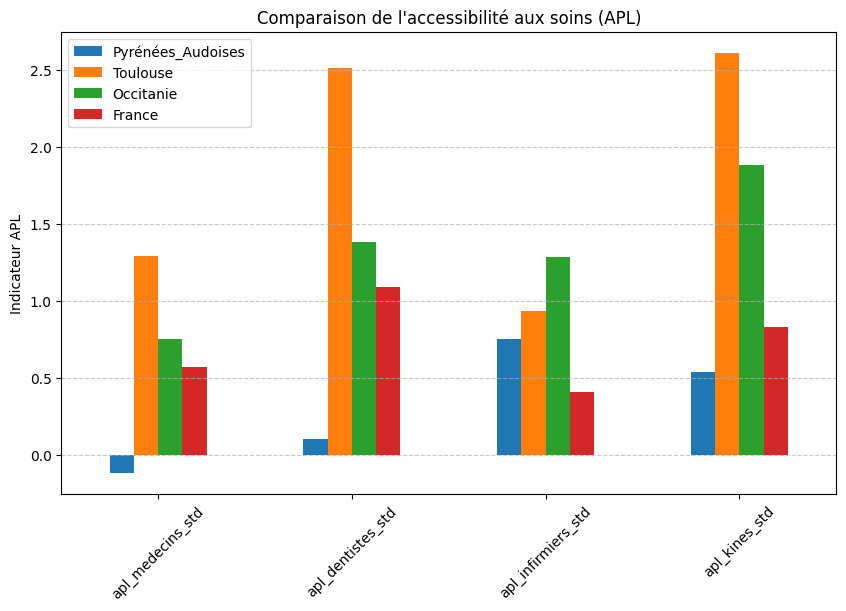

In [ ]:
import matplotlib.pyplot as plt

# On sélectionne uniquement les indicateurs de base (hors écarts)
cols_etude = ['apl_medecins_std', 'apl_dentistes_std', 'apl_infirmiers_std', 'apl_kines_std']

df_plot = comparaison.loc[cols_etude, [ 'Pyrénées_Audoises', 'Toulouse','Occitanie', 'France']]

df_plot.plot(kind='bar', figsize=(10, 6), rot=45)
plt.title("Comparaison de l'accessibilité aux soins (APL)")
plt.ylabel("Indicateur APL")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [90]:
def color_negative_red(val):
    color = 'red' if val < 0 else 'green'
    return f'color: {color}'

# On applique la couleur uniquement sur les colonnes d'écart
comparaison.style.applymap(color_negative_red, 
    subset=['Ecart Toulouse / Région (%)', 
            'Ecart Pyr Audoises / Région (%)', 
            'Ecart Toulouse / Pyr Audoises (%)'])

/var/folders/vr/hhxf111n55b91l_9j5qxjdrm0000gn/T/ipykernel_83242/271361762.py:6: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  comparaison.style.applymap(color_negative_red,


,Occitanie,Toulouse,Pyrénées_Audoises,France,Ecart Toulouse / Région (%),Ecart Pyr Audoises / Région (%),Ecart Toulouse / Pyr Audoises (%)
apl_medecins,3.942585,4.651362,2.800111,3.548408,17.977464,-28.977774,39.800176
apl_dentistes,66.510087,92.437808,37.036596,57.952660,38.983142,-44.314317,59.933498
apl_infirmiers,206.762892,182.876083,170.448788,140.788987,-11.552754,-17.563163,6.795473
apl_kines,167.098348,202.293808,101.882611,112.045359,21.062722,-39.028355,49.636317
apl_sagesfemmes,26.266038,28.208268,19.297745,20.229600,7.394453,-26.529670,31.588338
delta_apl_medecins,0.842736,1.587598,-0.023559,0.486054,88.386103,-102.795556,101.483950
delta_apl_dentistes,23.232446,46.051131,15.025667,15.392707,98.219036,-35.324647,67.371775
delta_apl_infirmiers,47.831697,52.017786,6.340025,17.121551,8.751703,-86.745140,87.811814
delta_apl_kines,57.736789,87.666394,17.513094,28.105984,51.838015,-69.667358,80.023025
delta_apl_sagesfemmes,6.840658,12.135565,2.485675,4.094040,77.403475,-63.663215,79.517433


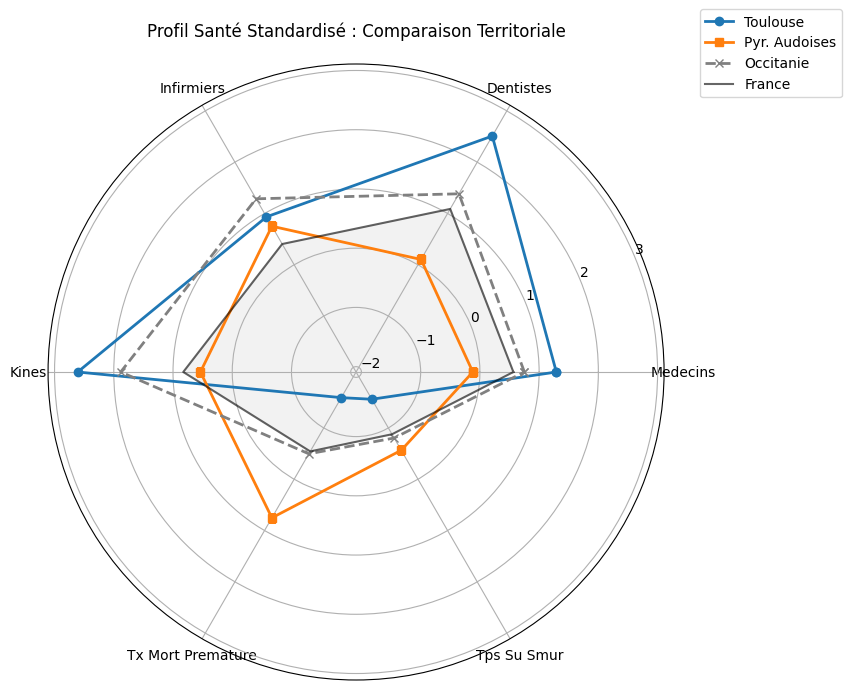

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Préparation des données
labels = ['apl_medecins_std', 'apl_dentistes_std', 'apl_infirmiers_std', 'apl_kines_std', 'tx_mort_premature_std','tps_SU_SMUR_std']
stats_toulouse = comparaison.loc[labels, 'Toulouse'].values
stats_pyr = comparaison.loc[labels, 'Pyrénées_Audoises'].values
stats_occ = comparaison.loc[labels, 'Occitanie'].values
# Ajout de la France dans les données
stats_france = comparaison.loc[labels, 'France'].values


# 2. Configuration des angles
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

# 3. Fermeture de la boucle pour le tracé (on répète le premier élément)
stats_toulouse = np.append(stats_toulouse, stats_toulouse[0])
stats_pyr = np.append(stats_pyr, stats_pyr[0])
stats_occ = np.append(stats_occ, stats_occ[0])
stats_france = np.append(stats_france, stats_france[0]) # Fermer la boucle

angles = np.append(angles, angles[0])

# 4. Création du graphique
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Tracé des lignes uniquement (sans remplissage)
ax.plot(angles, stats_toulouse, color='#1f77b4', linewidth=2, label='Toulouse', marker='o')
ax.plot(angles, stats_pyr, color='#ff7f0e', linewidth=2, label='Pyr. Audoises', marker='s')
ax.plot(angles, stats_occ, color='gray', linewidth=2, linestyle='--', label='Occitanie', marker='x')
ax.plot(angles, stats_france, color='black', linewidth=1.5, label='France', alpha=0.6)

# 5. Habillage
ax.set_xticks(angles[:-1])
# On simplifie les labels pour le graphique
clean_labels = [l.replace('_std', '').replace('apl_', '').replace('_', ' ').title() for l in labels]
ax.set_xticklabels(clean_labels)

# Un petit remplissage très léger pour la France peut servir de "zone neutre"
ax.fill(angles, stats_france, color='gray', alpha=0.10)

# Ajouter un cercle à zéro (la moyenne théorique)
ax.set_ylim(min(stats_pyr.min(), stats_toulouse.min()) - 0.5, 
            max(stats_pyr.max(), stats_toulouse.max()) + 0.5)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Profil Santé Standardisé : Comparaison Territoriale", pad=20)

plt.show()

In [ ]:
import geopandas as gpd

df_geom_epci = gpd.read_parquet(DATA_DIR / 'processed/geom/epci_geom_simplified.parquet')

df_geom_reg = gpd.read_parquet(DATA_DIR / 'processed/geom/regions_geom_simplified.parquet')

In [45]:
print(df_geom_epci.crs)
print(df_geom_reg.crs)

{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope": "Horizontal

In [46]:
df_geom_epci.columns

Index(['code_siren', 'nom_officiel', 'geometry', 'lon', 'lat'], dtype='object')

In [57]:
# Vérifions le format réel des SIREN dans votre fichier
print("--- Diagnostic SIREN ---")
print(f"Type de la colonne : {df_geom_reg['code_siren'].dtype}")
print(f"Exemples de valeurs : {df_geom_reg['code_siren'].head(5).tolist()}")

# Vérifions si nos cibles existent même partiellement
siren_toulouse = "243100518"
existe = siren_toulouse in df_geom_reg['code_siren'].astype(str).values
print(f"Est-ce que le SIREN de Toulouse est présent ? {existe}")

--- Diagnostic SIREN ---
Type de la colonne : object
Exemples de valeurs : ['234500023', '233500016', '200052264', '200053759', '200053791']
Est-ce que le SIREN de Toulouse est présent ? False


In [58]:
df_geom_reg.head()

,code_siren,nom_officiel,geometry,lon,lat,siren_num
0,234500023,Centre-Val de Loire,"POLYGON ((1.62329 48.74003, 1.62057 48.73609, ...",1.716113,47.643887,234500023
1,233500016,Bretagne,"MULTIPOLYGON (((-4.54119 48.01094, -4.54942 48...",-2.668907,48.155696,233500016
2,200052264,Grand Est,"POLYGON ((3.64051 48.18462, 3.63322 48.18888, ...",5.759323,48.794784,200052264
3,200053759,Nouvelle-Aquitaine,"MULTIPOLYGON (((-1.32594 44.08911, -1.31347 44...",0.104648,44.976923,200053759
4,200053791,Occitanie,"MULTIPOLYGON (((3.18249 43.16973, 3.18158 43.1...",2.117500,43.689861,200053791


/var/folders/vr/hhxf111n55b91l_9j5qxjdrm0000gn/T/ipykernel_83242/3416035512.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = subset.geometry.centroid.iloc[0]
/var/folders/vr/hhxf111n55b91l_9j5qxjdrm0000gn/T/ipykernel_83242/3416035512.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = subset.geometry.centroid.iloc[0]


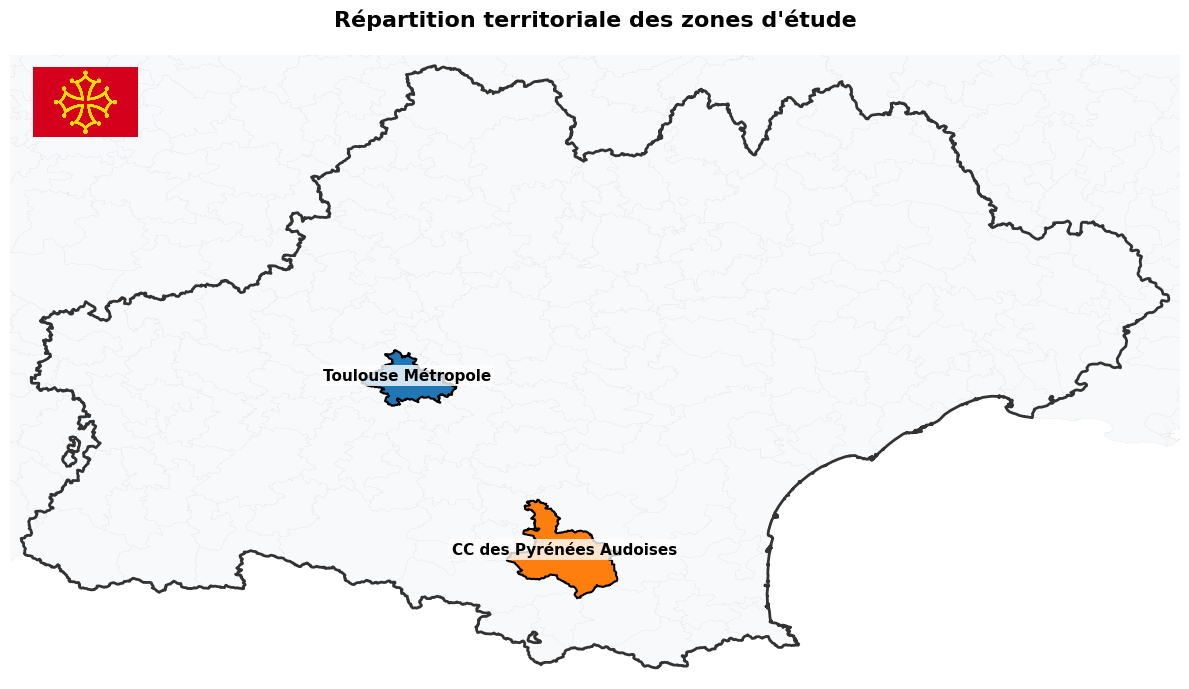

In [68]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os

# 1. Configuration des cibles et du zoom
siren_occ = '200053791'
region_occ = df_geom_reg[df_geom_reg['code_siren'] == siren_occ]
cibles = {
    '243100518': {'nom': 'Toulouse Métropole', 'color': '#1f77b4'},
    '200043776': {'nom': 'CC des Pyrénées Audoises', 'color': '#ff7f0e'}
}

fig, ax = plt.subplots(figsize=(12, 12))

# --- COUCHE 1 : EPCI et Cibles ---
df_geom_epci.plot(ax=ax, color='#f8f9fa', edgecolor='#dee2e6', linewidth=0.2)

for siren, info in cibles.items():
    subset = df_geom_epci[df_geom_epci['code_siren'] == siren]
    if not subset.empty:
        subset.plot(ax=ax, color=info['color'], edgecolor='black', linewidth=1.5)
        centroid = subset.geometry.centroid.iloc[0]
        ax.text(centroid.x, centroid.y, info['nom'], 
                fontsize=11, fontweight='bold', ha='center',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# --- COUCHE 2 : Bordure Région et Zoom ---
if not region_occ.empty:
    region_occ.plot(ax=ax, facecolor="none", edgecolor='#333333', linewidth=2)
    minx, miny, maxx, maxy = region_occ.total_bounds
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)

# --- COUCHE 3 : Ajout de l'Ecusson (Logo) ---
# 4. Ajout de l'écusson local (src/data/Occitanie.png)
    path_logo = '/Users/jean-jacques/code/jjchabutDataCRM/sante-territoires/src/data/Occitanie.png'
    if os.path.exists(path_logo):
        logo_img = plt.imread(path_logo)
        imagebox = OffsetImage(logo_img, zoom=0.15) # Ajustez le zoom selon la taille de votre PNG
        ab = AnnotationBbox(imagebox, (0.02, 0.98), xycoords='axes fraction', 
                            frameon=False, box_alignment=(0, 1))
        ax.add_artist(ab)

# 4. Finalisation
ax.set_aspect('equal')
ax.set_axis_off()
plt.title("Répartition territoriale des zones d'étude", fontsize=16, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [55]:
print(df_geom_reg['nom_officiel'].unique()[:10])

['Centre-Val de Loire' 'Bretagne' 'Grand Est' 'Nouvelle-Aquitaine'
 'Occitanie' 'Normandie' 'Auvergne-Rhône-Alpes'
 "Provence-Alpes-Côte d'Azur" 'Hauts-de-France' 'Bourgogne-Franche-Comté']


In [7]:
df_occitanie.head()

,code_insee_comm,nom_commune,population,superficie,apl_medecins,apl_65ans,apl_dentistes,apl_infirmiers,apl_kines,apl_sagesfemmes,...,codes_siren_des_epci,code_insee_de_la_region,tps_SU_SMUR,tx_mortalite,tx_mort_premature,tps_SU_SMUR_std,tx_mortalite_std,tx_mort_premature_std,apl_fragilite_std,score_fragilite_global
2831,09001,Aigues-Juntes,59.0,780.0,2.884,2.383,27.152,75.216,47.354,23.574,...,200067940,76,18.0,12.8,2.1,-0.441289,0.893947,0.752452,0.306839,0.206001
2832,09002,Aigues-Vives,631.0,520.0,4.416,3.240,19.027,230.760,140.083,3.480,...,200044469,76,12.0,12.8,2.1,-0.945998,0.893947,0.752452,-0.893393,-0.362313
2833,09003,L'Aiguillon,375.0,640.0,3.097,3.097,15.553,231.298,125.761,1.946,...,240900464,76,7.5,12.8,2.1,-1.324530,0.893947,0.752452,-0.453680,-0.341919
2834,09004,Albiès,122.0,770.0,2.322,1.792,37.740,139.960,121.445,40.841,...,200066363,76,31.0,12.8,2.1,0.652248,0.893947,0.752452,-0.250997,0.384568
2835,09005,Aleu,131.0,1390.0,2.215,2.215,5.465,85.913,107.679,4.404,...,200067940,76,27.0,12.8,2.1,0.315775,0.893947,0.752452,0.443222,0.503816


In [12]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 42.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [13]:
import plotly.express as px

fig = px.scatter(
    df_occitanie, 
    x='tps_SU_SMUR_std', 
    y='tx_mort_premature_std',
    hover_name='nom_commune',
    color='score_fragilite_global', 
    trendline="ols", 
    template="plotly_white", # Optionnel : fond blanc plus propre pour les rapports
    title="<b>Corrélation : Éloignement des Urgences vs Mortalité</b><br><sup>Occitanie - Z-Scores</sup>"
)

# Ajout des lignes de référence (moyenne = 0)
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.7)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.7)

# Personnalisation des axes pour plus de clarté
fig.update_layout(
    xaxis_title="Éloignement SMUR (Standardisé)",
    yaxis_title="Mortalité Prématurée (Standardisée)",
    legend_title="Score de Fragilité"
)

# Commande spécifique pour l'affichage en Notebook
fig.show()

/var/folders/vr/hhxf111n55b91l_9j5qxjdrm0000gn/T/ipykernel_32791/1102350084.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/vr/hhxf111n55b91l_9j5qxjdrm0000gn/T/ipykernel_32791/1102350084.py:27: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



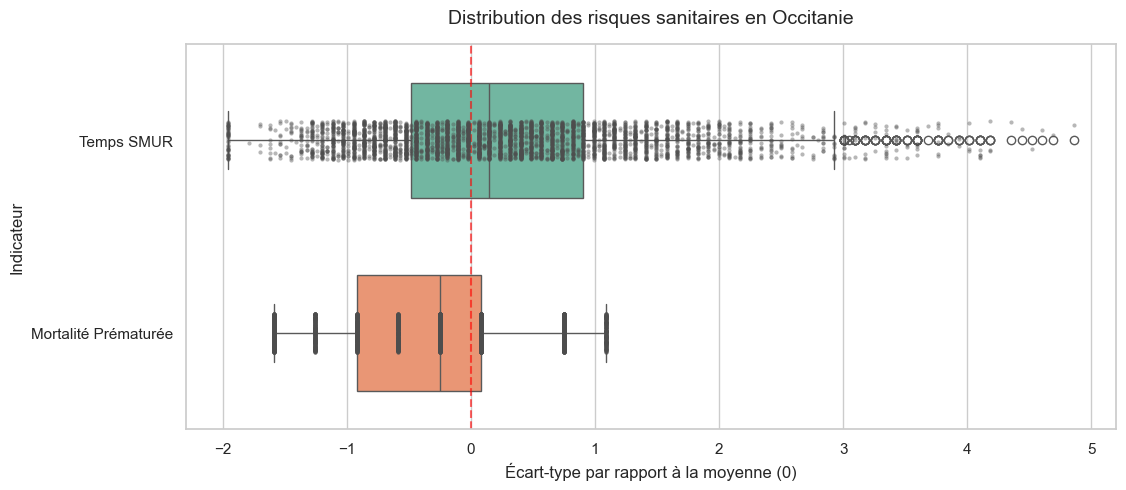

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuration du style Seaborn pour un rendu "pro"
sns.set_theme(style="whitegrid")

# 2. Création de la figure
fig, ax = plt.subplots(figsize=(12, 5))

# 3. Préparation des données (Melt)
# On transforme le format large en format long pour que Seaborn sépare les catégories
df_melted = df_occitanie.melt(value_vars=['tps_SU_SMUR_std', 'tx_mort_premature_std'], 
                             var_name='Indicateur', 
                             value_name='Z-Score')

# 4. Tracé du Boxplot
sns.boxplot(data=df_melted, x='Z-Score', y='Indicateur', ax=ax, palette="Set2", width=0.6)

# 5. Ajout d'un "Stripplot" par-dessus (Optionnel mais recommandé)
# Cela permet de voir chaque commune sous forme de point pour repérer les extrêmes
sns.stripplot(data=df_melted, x='Z-Score', y='Indicateur', color=".3", size=3, alpha=0.4, ax=ax)

# 6. Habillage
ax.set_title("Distribution des risques sanitaires en Occitanie", fontsize=14, pad=15)
ax.axvline(0, color='red', linestyle='--', alpha=0.6, label="Moyenne régionale")
ax.set_xlabel("Écart-type par rapport à la moyenne (0)")
ax.set_yticklabels(['Temps SMUR', 'Mortalité Prématurée'])

# Affichage direct dans le Notebook
plt.show()

/var/folders/vr/hhxf111n55b91l_9j5qxjdrm0000gn/T/ipykernel_32791/1908399049.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




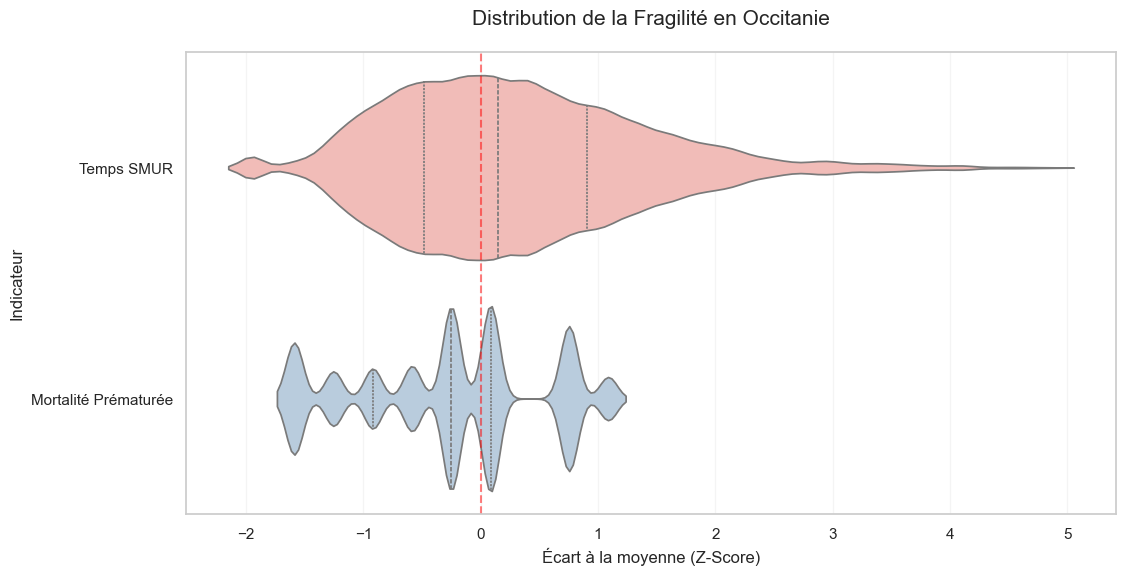

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Préparation (Melt pour avoir une colonne 'Indicateur' et une colonne 'Valeur')
df_violin = df_occitanie.melt(
    value_vars=['tps_SU_SMUR_std', 'tx_mort_premature_std'],
    var_name='Indicateur',
    value_name='Z-Score'
)

# 2. Création du graphique
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_violin, 
    x='Z-Score', 
    y='Indicateur', 
    inner="quart", # Affiche la médiane et les quartiles à l'intérieur
    palette="Pastel1",
    bw_adjust=.5 # Ajuste le lissage pour voir plus de détails
)

# 3. On ajoute une ligne pour la moyenne (0)
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Moyenne France')

# 4. Nettoyage des labels
plt.title("Distribution de la Fragilité en Occitanie", fontsize=15, pad=20)
plt.yticks([0, 1], ['Temps SMUR', 'Mortalité Prématurée'])
plt.xlabel("Écart à la moyenne (Z-Score)")
plt.grid(axis='x', alpha=0.2)

plt.show()